In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

fred = Fred(api_key=os.getenv("FRED_API_KEY"))

pd.set_option("display.float_format", "{:.4f}".format)

# ── Series to pull ─────────────────────────────────────────
FRED_SERIES = {
    "UNRATE":     "Unemployment Rate (%)",
    "DRCCLACBS":  "Credit Card Delinquency Rate (%)",
    "FEDFUNDS":   "Federal Funds Rate (%)",
    "UMCSENT":    "Consumer Sentiment Index",
}

START = "2014-01-01"  # extra year for z-score baseline
END   = "2018-12-31"

print("FRED series to pull:")
for k, v in FRED_SERIES.items():
    print(f"  {k:<12} — {v}")
print(f"\nDate range: {START} → {END}")

FRED series to pull:
  UNRATE       — Unemployment Rate (%)
  DRCCLACBS    — Credit Card Delinquency Rate (%)
  FEDFUNDS     — Federal Funds Rate (%)
  UMCSENT      — Consumer Sentiment Index

Date range: 2014-01-01 → 2018-12-31


In [2]:
# ── Pull all four series ───────────────────────────────────
raw = {}
for series_id in FRED_SERIES.keys():
    s = fred.get_series(series_id,
                        observation_start=START,
                        observation_end=END)
    raw[series_id] = s
    print(f"{series_id:<12} — {len(s)} observations  "
          f"freq: {s.index.to_series().diff().median().days:.0f} days  "
          f"range: {s.min():.2f} – {s.max():.2f}")

# ── Align to monthly index ─────────────────────────────────
monthly_idx = pd.date_range(start="2015-01-01", end="2018-12-01", freq="MS")

df_macro = pd.DataFrame(index=monthly_idx)

for series_id, s in raw.items():
    # Resample to month-start — forward fill for quarterly series
    s_monthly = s.resample("MS").last().reindex(monthly_idx, method="ffill")
    df_macro[series_id] = s_monthly

print(f"\nAligned macro dataframe: {df_macro.shape}")
print(f"Null counts:\n{df_macro.isnull().sum()}")
print(f"\nSample:\n{df_macro.head(6).to_string()}")

UNRATE       — 60 observations  freq: 31 days  range: 3.70 – 6.70
DRCCLACBS    — 20 observations  freq: 91 days  range: 2.11 – 2.54
FEDFUNDS     — 60 observations  freq: 31 days  range: 0.07 – 2.27
UMCSENT      — 60 observations  freq: 31 days  range: 80.00 – 101.40

Aligned macro dataframe: (48, 4)
Null counts:
UNRATE        0
DRCCLACBS    30
FEDFUNDS      0
UMCSENT       0
dtype: int64

Sample:
            UNRATE  DRCCLACBS  FEDFUNDS  UMCSENT
2015-01-01  5.7000     2.1100    0.1100  98.1000
2015-02-01  5.5000        NaN    0.1100  95.4000
2015-03-01  5.4000        NaN    0.1100  93.0000
2015-04-01  5.4000     2.1200    0.1200  95.9000
2015-05-01  5.6000        NaN    0.1200  90.7000
2015-06-01  5.3000        NaN    0.1300  96.1000


In [7]:
# ── Forward-fill DRCCLACBS quarterly gaps ─────────────────
df_macro["DRCCLACBS"] = df_macro["DRCCLACBS"].ffill()

print("Null counts after forward-fill:")
print(df_macro.isnull().sum())

# ── Normalise to z-scores using 2015 baseline ─────────────
baseline      = df_macro.loc["2015-01-01":"2015-12-01"]
baseline_mean = baseline.mean()
baseline_std  = baseline.std()

print(f"\n2015 Baseline statistics:")
for col in df_macro.columns:
    print(f"  {col:<12}  mean: {baseline_mean[col]:.3f}  std: {baseline_std[col]:.3f}")

df_zscore = (df_macro - baseline_mean) / baseline_std

# ── Clip z-scores to ±3 to prevent single series dominating ──
df_zscore_clipped = df_zscore[["UNRATE", "DRCCLACBS", "FEDFUNDS", "UMCSENT"]].clip(-3, 3)

print("\nZ-score ranges after clipping:")
for col in ["UNRATE", "DRCCLACBS", "FEDFUNDS", "UMCSENT"]:
    print(f"  {col:<12}  min: {df_zscore_clipped[col].min():.2f}  max: {df_zscore_clipped[col].max():.2f}")

# ── Invert UMCSENT — higher sentiment = lower risk ────────
df_zscore_clipped["UMCSENT"] = -df_zscore_clipped["UMCSENT"]

# ── Composite macro_score ──────────────────────────────────
# UNRATE:    30% — unemployment drives default risk
# DRCCLACBS: 30% — credit card delinquency is direct signal
# FEDFUNDS:  20% — rate environment affects repayment burden
# UMCSENT:   20% — consumer confidence leads behaviour
weights = {
    "UNRATE":    0.30,
    "DRCCLACBS": 0.30,
    "FEDFUNDS":  0.20,
    "UMCSENT":   0.20,
}

df_zscore_clipped["macro_score"] = sum(
    df_zscore_clipped[col] * w for col, w in weights.items()
)

print(f"\nmacro_score range: {df_zscore_clipped['macro_score'].min():.3f} – {df_zscore_clipped['macro_score'].max():.3f}")
print(f"macro_score mean:  {df_zscore_clipped['macro_score'].mean():.3f}")
print(f"macro_score std:   {df_zscore_clipped['macro_score'].std():.3f}")

print(f"\nSample macro_score (first 12 months):")
print(df_zscore_clipped["macro_score"].head(12).round(3).to_string())

Null counts after forward-fill:
UNRATE       0
DRCCLACBS    0
FEDFUNDS     0
UMCSENT      0
dtype: int64

2015 Baseline statistics:
  UNRATE        mean: 5.275  std: 0.245
  DRCCLACBS     mean: 2.135  std: 0.022
  FEDFUNDS      mean: 0.133  std: 0.035
  UMCSENT       mean: 92.942  std: 3.044

Z-score ranges after clipping:
  UNRATE        min: -3.00  max: 1.73
  DRCCLACBS     min: -1.16  max: 3.00
  FEDFUNDS      min: -0.63  max: 3.00
  UMCSENT       min: -1.89  max: 2.78

macro_score range: -0.400 – 1.545
macro_score mean:  0.381
macro_score std:   0.432

Sample macro_score (first 12 months):
2015-01-01   -0.2950
2015-02-01   -0.3620
2015-03-01   -0.3260
2015-04-01   -0.3210
2015-05-01    0.2650
2015-06-01   -0.4000
2015-07-01    0.0930
2015-08-01    0.1060
2015-09-01    0.2920
2015-10-01    0.1350
2015-11-01    0.1720
2015-12-01    0.6350
Freq: MS


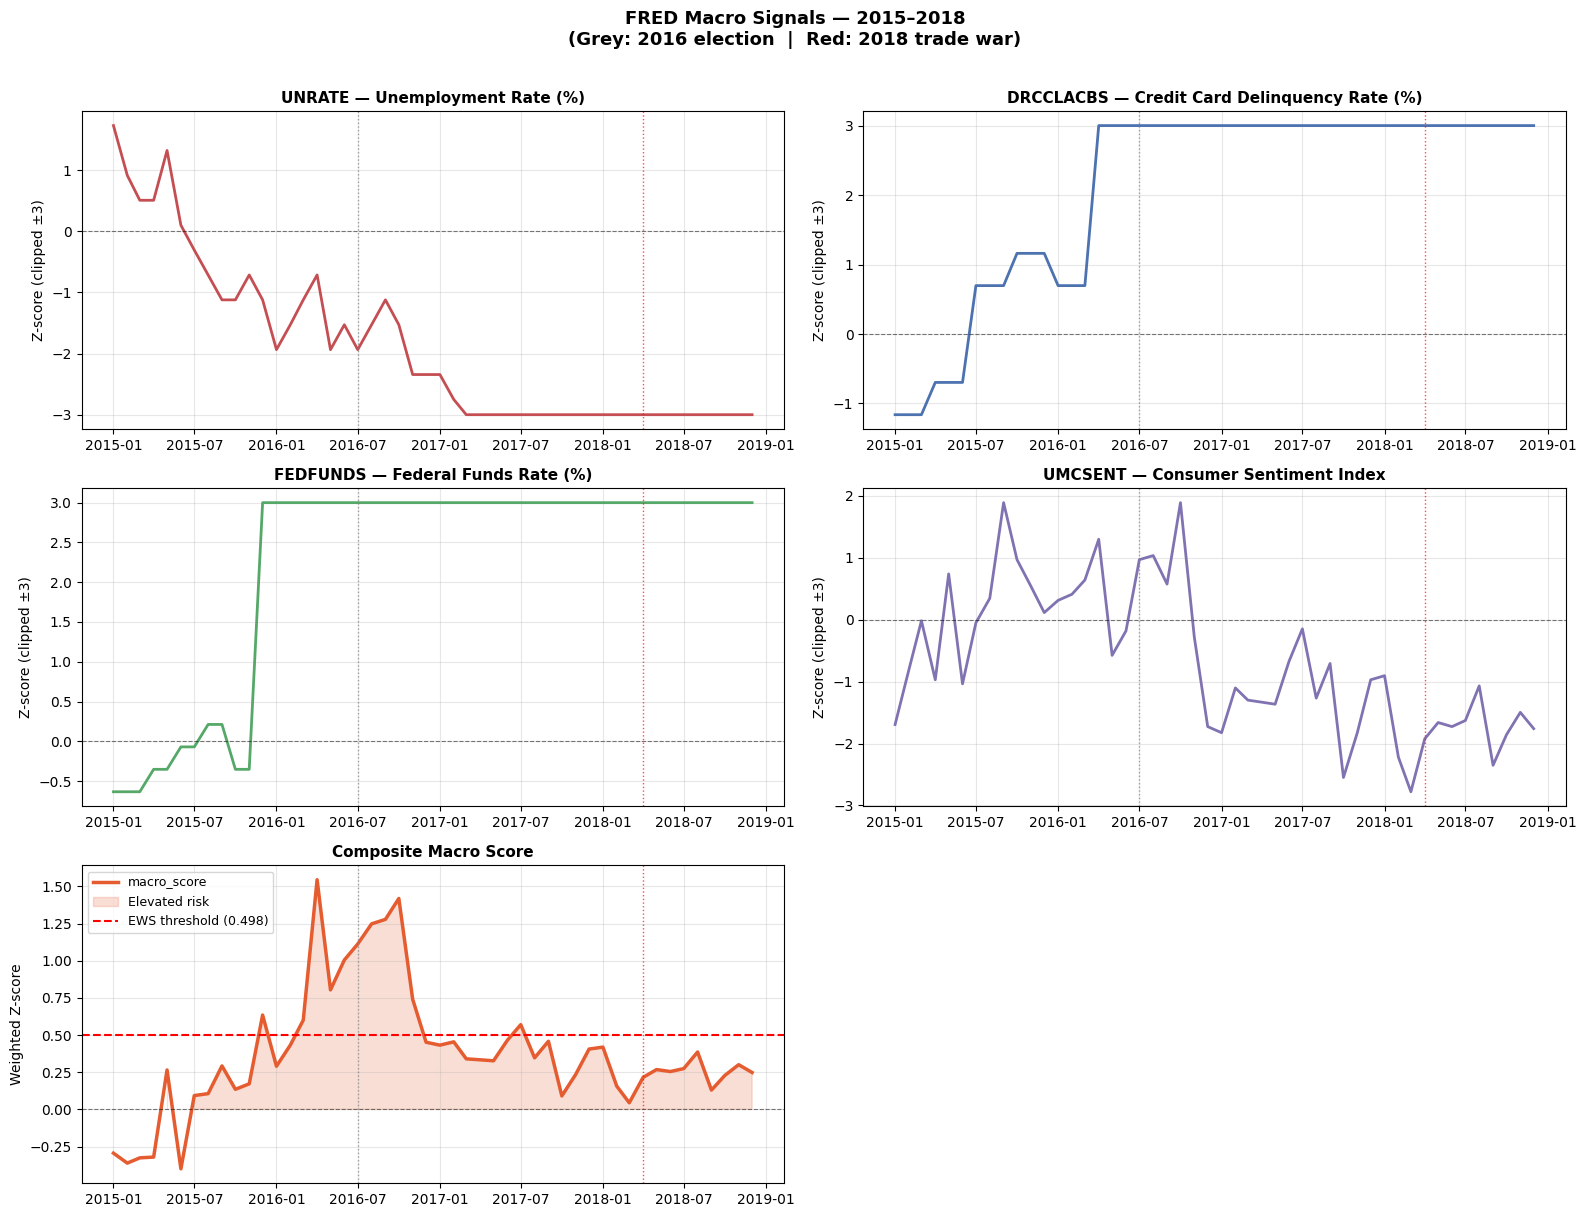

Saved → outputs/fred_macro_signals.png
Saved → data/processed/fred_macro_score.csv
Saved → data/processed/fred_macro_score.pkl

EWS threshold (2015 mean + 1.5σ): 0.4976
Months above threshold: 11


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# ── Plot 1-4: Individual z-scored series ──────────────────
series_colors = {
    "UNRATE":    "#C44E52",
    "DRCCLACBS": "#4C72B0",
    "FEDFUNDS":  "#55A868",
    "UMCSENT":   "#8172B2",
}

for i, (col, label) in enumerate(FRED_SERIES.items()):
    ax = axes[i]
    ax.plot(df_zscore_clipped.index, df_zscore_clipped[col],
            color=series_colors[col], linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(pd.Timestamp("2016-07-01"), color="gray",
               linestyle=":", linewidth=1, alpha=0.7)
    ax.axvline(pd.Timestamp("2018-04-01"), color="red",
               linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(f"{col} — {label}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Z-score (clipped ±3)")
    ax.grid(alpha=0.3)

# ── Plot 5: Composite macro_score ─────────────────────────
ax5 = axes[4]
macro = df_zscore_clipped["macro_score"]

ax5.plot(macro.index, macro.values, color="#E55C30",
         linewidth=2.5, label="macro_score")
ax5.fill_between(macro.index, macro.values, 0,
                 where=macro.values > 0,
                 color="#E55C30", alpha=0.2, label="Elevated risk")

# EWS trigger threshold — 2015 mean + 1.5 std
threshold = macro.loc["2015-01-01":"2015-12-01"].mean() + \
            1.5 * macro.loc["2015-01-01":"2015-12-01"].std()
ax5.axhline(threshold, color="red", linestyle="--",
            linewidth=1.5, label=f"EWS threshold ({threshold:.3f})")
ax5.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax5.axvline(pd.Timestamp("2016-07-01"), color="gray",
            linestyle=":", linewidth=1, alpha=0.7)
ax5.axvline(pd.Timestamp("2018-04-01"), color="red",
            linestyle=":", linewidth=1, alpha=0.7)
ax5.set_title("Composite Macro Score", fontsize=11, fontweight="bold")
ax5.set_ylabel("Weighted Z-score")
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle("FRED Macro Signals — 2015–2018\n"
             "(Grey: 2016 election  |  Red: 2018 trade war)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/fred_macro_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/fred_macro_signals.png")

# ── Save macro_score ───────────────────────────────────────
macro_out = df_zscore_clipped[["UNRATE", "DRCCLACBS",
                                "FEDFUNDS", "UMCSENT", "macro_score"]].copy()
macro_out.index.name = "date"
macro_out.to_csv("../data/processed/fred_macro_score.csv")
macro_out.to_pickle("../data/processed/fred_macro_score.pkl")

print("Saved → data/processed/fred_macro_score.csv")
print("Saved → data/processed/fred_macro_score.pkl")

print(f"\nEWS threshold (2015 mean + 1.5σ): {threshold:.4f}")
print(f"Months above threshold: {(macro > threshold).sum()}")

This notebook pulls four macroeconomic time series from the Federal Reserve Economic Data (FRED) API, normalises them to z-scores using 2015 as the baseline year, and constructs a single composite `macro_score` that will serve as one of the two input streams for the Early Warning System (EWS) in Notebook 14.

The logic is that macro conditions observable at the time of lending are leading indicators of future default rates. Rising unemployment, rising credit card delinquencies, rising interest rates, and falling consumer confidence should all predict rising defaults — and combining them into a single score gives a cleaner signal than any one series alone.

**Why z-scores?** Each series is on a different scale (%, index points). Z-scoring makes them comparable and anchors them to 2015 conditions so movements are expressed as deviations from the baseline period.

**Why clip at ±3?** FEDFUNDS rose from near-zero to 2.27% against a 2015 std of 0.035%, producing z-scores above 60. Clipping prevents any single series from dominating the composite.

---

### Series Pulled from FRED
| Series | Description | Frequency | Risk Direction |
|---|---|---|---|
| UNRATE | Unemployment Rate (%) | Monthly | Higher = more risk |
| DRCCLACBS | Credit Card Delinquency Rate (%) | Quarterly → forward-filled | Higher = more risk |
| FEDFUNDS | Federal Funds Rate (%) | Monthly | Higher = more risk |
| UMCSENT | Consumer Sentiment Index | Monthly | Higher = less risk (inverted) |

---

### Composite macro_score Construction
| Component | Weight | Rationale |
|---|---|---|
| UNRATE z-score | 30% | Direct driver of borrower distress |
| DRCCLACBS z-score | 30% | Real-time credit stress signal |
| FEDFUNDS z-score | 20% | Repayment burden environment |
| UMCSENT z-score (inverted) | 20% | Leading behavioural indicator |

---

### Results
| Metric | Value |
|---|---|
| macro_score range | -0.400 – 1.545 |
| macro_score mean | 0.381 |
| macro_score std | 0.432 |
| EWS threshold (2015 mean + 1.5σ) | 0.498 |
| Months above threshold | 11 / 48 (23%) |

---

### Key Observations
- macro_score near zero in early 2015 (baseline period — expected)
- Peaks mid-2016 driven by FEDFUNDS rate hike and DRCCLACBS rise
- Stays elevated through 2017–2018 as rates continue rising
- 11 flagged months concentrated in 2016 Q2 – 2018 Q4

---

### Files Saved
- `data/processed/fred_macro_score.csv`
- `data/processed/fred_macro_score.pkl`
- `outputs/fred_macro_signals.png`
